# Notebook 2: U-Net training workflow for CT segmentation

## 1. Introduction

In this notebook, we will walk through a basic U-Net training workflow for CT image segmentation.

The aim is to show how the prepared image-mask datasets from Notebook 1 can be used to train a binary segmentation model. We will use the `segmentation_models` library, which provides convenient implementations of common segmentation architectures such as U-Net.

This notebook is intended as a training walkthrough rather than the main live exercise. In the workshop, participants will run inference using a pretrained model in the next notebook.

The workflow covered here is:

1. collect image-mask file pairs;
2. split training data into training and validation sets;
3. preprocess CT images and binary masks;
4. build a U-Net model;
5. train with Dice and IoU metrics;
6. use early stopping to avoid unnecessary training;
7. save the trained model.

The final model evaluation and inference workflow are covered in Notebook 3.

## 2. Imports and paths

We start by importing the libraries needed for training.

This notebook uses TensorFlow/Keras and `segmentation_models`. The `SM_FRAMEWORK` environment variable is set before importing `segmentation_models` so that it uses `tf.keras`.

In [1]:
from pathlib import Path
import os

import utils

# segmentation_models needs this set before importing the package
os.environ["SM_FRAMEWORK"] = "tf.keras"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tifffile import imread
from sklearn.model_selection import train_test_split

import tensorflow as tf
import segmentation_models as sm

# Plot settings
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["image.cmap"] = "gray"

# Reproducibility
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

2026-06-10 01:00:51.367805: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-10 01:00:51.380299: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781049651.393896  349868 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781049651.397431  349868 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781049651.407466  349868 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Segmentation Models: using `tf.keras` framework.


In [2]:
def find_project_root(start_path=Path.cwd()):
    """Find the repository root from the current notebook location."""
    start_path = Path(start_path).resolve()

    for path in [start_path, *start_path.parents]:
        if (
            (path / "environment.yml").exists()
            and (path / "notebooks").exists()
            and (path / "data").exists()
        ):
            return path

    raise FileNotFoundError("Could not find the project root.")

In [3]:
PROJECT_DIR = find_project_root()
DATA_DIR = PROJECT_DIR / "data" / "afternoon"

AUG_SIM_DATA_DIR = DATA_DIR / "augmented_simulated_data"
AUG_REAL_DATA_DIR = DATA_DIR / "augmented_real_data"

AUG_SIM_CT_DIR = AUG_SIM_DATA_DIR / "CT_data"
AUG_SIM_LABEL_DIR = AUG_SIM_DATA_DIR / "Labels"

REAL_TRAIN_CT_DIR = AUG_REAL_DATA_DIR / "train" / "CT_data"
REAL_TRAIN_LABEL_DIR = AUG_REAL_DATA_DIR / "train" / "Labels"

REAL_TEST_CT_DIR = AUG_REAL_DATA_DIR / "test" / "CT_data"
REAL_TEST_LABEL_DIR = AUG_REAL_DATA_DIR / "test" / "Labels"

MODEL_DIR = DATA_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project directory: {PROJECT_DIR}")
print(f"Data directory:    {DATA_DIR}")
print(f"Model directory:   {MODEL_DIR}")

Project directory: /home/ucecmjo/Data/gVXR-training-dXCT2026
Data directory:    /home/ucecmjo/Data/gVXR-training-dXCT2026/data/afternoon
Model directory:   /home/ucecmjo/Data/gVXR-training-dXCT2026/data/afternoon/models


In [4]:
required_dirs = [
    AUG_SIM_CT_DIR,
    AUG_SIM_LABEL_DIR,
    REAL_TRAIN_CT_DIR,
    REAL_TRAIN_LABEL_DIR,
]

for directory in required_dirs:
    if not directory.exists():
        raise FileNotFoundError(f"Required directory not found: {directory}")

print("Required training directories found.")

Required training directories found.


## 3. Build image-mask pair tables

We now build tables linking each CT image to its corresponding binary mask.

The training set will combine:

- augmented simulated data;
- augmented real training data.

The real test data are not used in this notebook. They will be used in the inference and evaluation notebook.

In [5]:
def build_pairs_from_prefixes(ct_dir, label_dir, ct_prefix, label_prefix, source):
    """
    Build an image-mask pair table from matching CT and label filenames.

    The key is the shared part of the filename after removing the prefix.
    """
    rows = []

    for ct_path in sorted(ct_dir.glob(f"{ct_prefix}*.tiff")):
        key = ct_path.stem.removeprefix(ct_prefix)
        label_path = label_dir / f"{label_prefix}{key}.tiff"

        rows.append(
            {
                "key": key,
                "ct_path": ct_path,
                "label_path": label_path,
                "label_exists": label_path.exists(),
                "source": source,
            }
        )

    pairs = pd.DataFrame(rows)

    if len(pairs) == 0:
        raise FileNotFoundError(f"No CT files found in {ct_dir}")

    missing = pairs.loc[~pairs["label_exists"]]

    if len(missing) > 0:
        display(missing)
        raise FileNotFoundError(
            f"{len(missing)} CT files do not have matching label files."
        )

    return pairs.drop(columns="label_exists")

In [6]:
sim_pairs = build_pairs_from_prefixes(
    ct_dir=AUG_SIM_CT_DIR,
    label_dir=AUG_SIM_LABEL_DIR,
    ct_prefix="CT-",
    label_prefix="labels-",
    source="simulated",
)

real_train_pairs = build_pairs_from_prefixes(
    ct_dir=REAL_TRAIN_CT_DIR,
    label_dir=REAL_TRAIN_LABEL_DIR,
    ct_prefix="CT-",
    label_prefix="labels-",
    source="real_train",
)

print(f"Simulated training pairs: {len(sim_pairs)}")
print(f"Real training pairs:      {len(real_train_pairs)}")

Simulated training pairs: 3600
Real training pairs:      360


In [7]:
all_training_pairs = pd.concat(
    [sim_pairs, real_train_pairs],
    ignore_index=True,
)

all_training_pairs.head()

,key,ct_path,label_path,source
0,1-180_0-120_0-0_5-112_0_aug_000,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,simulated
1,1-180_0-120_0-0_5-136_0_aug_000,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,simulated
2,1-180_0-120_0-0_5-160_0_aug_000,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,simulated
3,1-180_0-120_0-0_5-184_0_aug_000,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,simulated
4,1-180_0-120_0-0_5-208_0_aug_000,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,simulated


### Training and validation split

We split the available training pairs into training and validation sets.

The validation set is used during training to monitor whether the model is improving on data it has not directly optimised against.

In [8]:
train_pairs, val_pairs = train_test_split(
    all_training_pairs,
    test_size=0.2,
    random_state=RANDOM_SEED,
    shuffle=True,
    stratify=all_training_pairs["source"],
)

train_pairs = train_pairs.reset_index(drop=True)
val_pairs = val_pairs.reset_index(drop=True)

print(f"Training pairs:   {len(train_pairs)}")
print(f"Validation pairs: {len(val_pairs)}")

Training pairs:   3168
Validation pairs: 792


In [9]:
print("Training sources:")
display(train_pairs["source"].value_counts())

print("Validation sources:")
display(val_pairs["source"].value_counts())

Training sources:


source
simulated     2880
real_train     288
Name: count, dtype: int64

Validation sources:


source
simulated     720
real_train     72
Name: count, dtype: int64

## 4. Inspect example image-mask pairs

Before training, it is useful to visually check that the CT images and masks load correctly.

Source: simulated
CT path: /home/ucecmjo/Data/gVXR-training-dXCT2026/data/afternoon/augmented_simulated_data/CT_data/CT-3-198_0-150_0-1_42-136_0_aug_000.tiff
Label path: /home/ucecmjo/Data/gVXR-training-dXCT2026/data/afternoon/augmented_simulated_data/Labels/labels-3-198_0-150_0-1_42-136_0_aug_000.tiff


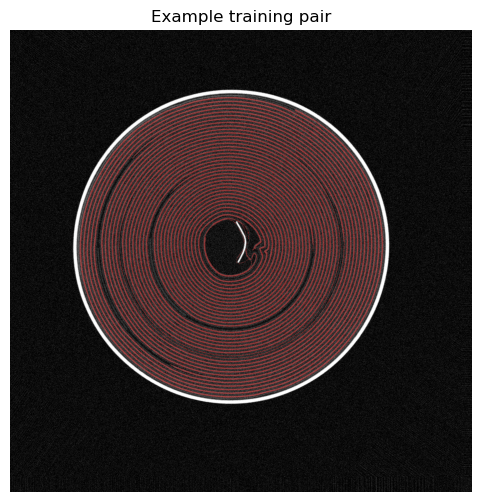

In [10]:
example = train_pairs.iloc[0]

print(f"Source: {example['source']}")
print(f"CT path: {example['ct_path']}")
print(f"Label path: {example['label_path']}")

utils.plot_pair_overlay(example, title="Example training pair")

Source: simulated


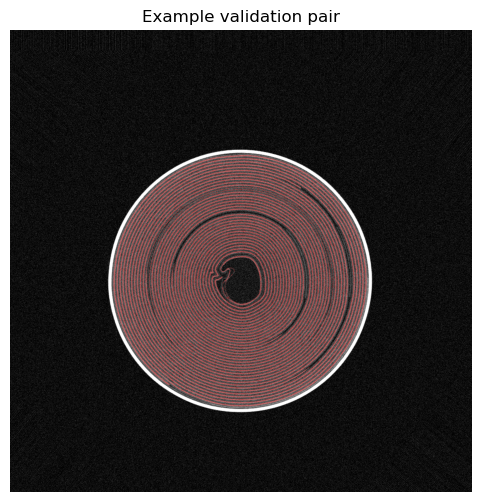

In [11]:
example = val_pairs.iloc[0]

print(f"Source: {example['source']}")
utils.plot_pair_overlay(example, title="Example validation pair")

## 5. Preprocess images and masks

The model expects images and masks to have consistent shapes and value ranges.

For this notebook we will:

- read each CT image as `float32`;
- normalise the CT image to the range `0–1`;
- read each mask as a binary `uint8` image;
- resize images and masks to a fixed model input size;
- add a channel dimension so the arrays have shape `(height, width, 1)`.

The CT images use linear interpolation when resized. The masks use nearest-neighbour interpolation so that label values remain binary.

In [12]:
from skimage.transform import resize

IMAGE_SIZE = 1024
N_CHANNELS = 1

INPUT_SHAPE = (IMAGE_SIZE, IMAGE_SIZE, N_CHANNELS)

print(f"Model input shape: {INPUT_SHAPE}")

Model input shape: (1024, 1024, 1)


In [13]:
def normalise_image(image, lower=1, upper=99):
    """Percentile-normalise a CT image to the range 0–1."""
    image = image.astype(np.float32)
    vmin, vmax = np.percentile(image, [lower, upper])

    if vmax <= vmin:
        return np.zeros_like(image, dtype=np.float32)

    image = np.clip(image, vmin, vmax)
    image = (image - vmin) / (vmax - vmin)

    return image.astype(np.float32)


def load_and_preprocess_pair(ct_path, label_path, image_size=IMAGE_SIZE):
    """Load and preprocess one CT image and binary mask."""

    # Decode TensorFlow byte strings to normal Python strings
    if isinstance(ct_path, bytes):
        ct_path = ct_path.decode("utf-8")

    if isinstance(label_path, bytes):
        label_path = label_path.decode("utf-8")

    image = imread(ct_path).astype(np.float32)
    mask = imread(label_path).astype(np.uint8)

    image = normalise_image(image)
    mask = (mask > 0).astype(np.uint8)

    image = resize(
        image,
        (image_size, image_size),
        order=1,
        preserve_range=True,
        anti_aliasing=True,
    ).astype(np.float32)

    mask = resize(
        mask,
        (image_size, image_size),
        order=0,
        preserve_range=True,
        anti_aliasing=False,
    ).astype(np.uint8)

    image = image[..., np.newaxis]
    mask = mask[..., np.newaxis].astype(np.float32)

    return image, mask

In [14]:
image, mask = load_and_preprocess_pair(
    train_pairs.iloc[0]["ct_path"],
    train_pairs.iloc[0]["label_path"],
)

print(f"Image shape: {image.shape}, dtype: {image.dtype}, range: {image.min():.3f}–{image.max():.3f}")
print(f"Mask shape:  {mask.shape}, dtype: {mask.dtype}, labels: {np.unique(mask)}")

Image shape: (1024, 1024, 1), dtype: float32, range: 0.000–1.000
Mask shape:  (1024, 1024, 1), dtype: float32, labels: [0. 1.]


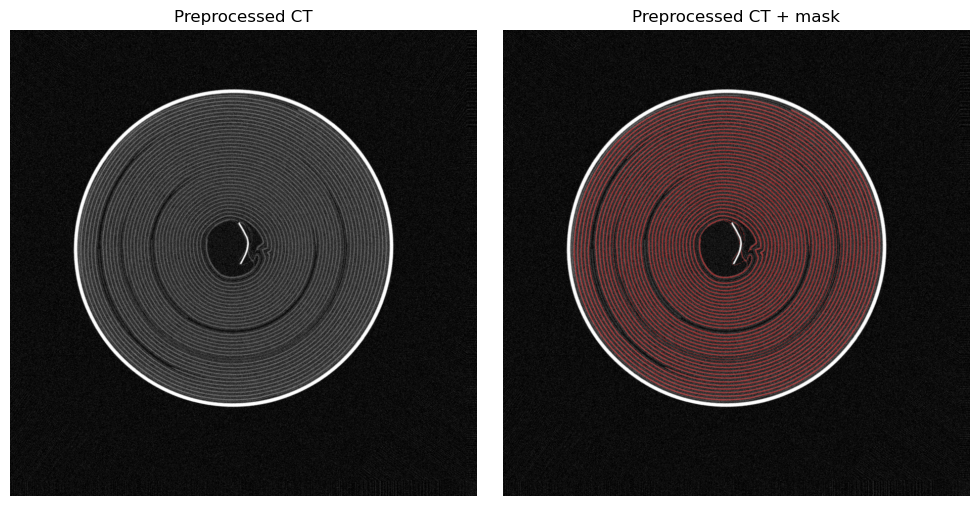

In [15]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image[..., 0], cmap="gray")
plt.title("Preprocessed CT")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image[..., 0], cmap="gray")
plt.imshow(utils.make_red_overlay(mask[..., 0]))
plt.title("Preprocessed CT + mask")
plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Create TensorFlow datasets

We now convert the image-mask tables into TensorFlow datasets.

Each dataset will load TIFF files from disk, preprocess them, batch them, and prefetch data during training.

In [16]:
BATCH_SIZE = 1
AUTOTUNE = tf.data.AUTOTUNE

def load_pair_tf(ct_path, label_path):
    """TensorFlow wrapper around the NumPy/TIFF preprocessing function."""

    image, mask = tf.numpy_function(
        func=load_and_preprocess_pair,
        inp=[ct_path, label_path],
        Tout=[tf.float32, tf.float32],
    )

    image.set_shape(INPUT_SHAPE)
    mask.set_shape(INPUT_SHAPE)

    return image, mask

In [17]:
def make_dataset(pairs, batch_size=BATCH_SIZE, shuffle=False):
    """Create a TensorFlow dataset from a dataframe of image-mask pairs."""
    ct_paths = pairs["ct_path"].astype(str).values
    label_paths = pairs["label_path"].astype(str).values

    dataset = tf.data.Dataset.from_tensor_slices((ct_paths, label_paths))

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(pairs),
            seed=RANDOM_SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(load_pair_tf, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

In [18]:
train_dataset = make_dataset(
    train_pairs,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_dataset = make_dataset(
    val_pairs,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print(train_dataset)
print(val_dataset)

I0000 00:00:1781049653.864466  349868 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18285 MB memory:  -> device: 0, name: NVIDIA RTX 4000 Ada Generation, pci bus id: 0000:ac:00.0, compute capability: 8.9
I0000 00:00:1781049653.865717  349868 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 18312 MB memory:  -> device: 1, name: NVIDIA RTX 4000 Ada Generation, pci bus id: 0000:ca:00.0, compute capability: 8.9


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 1024, 1024, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1024, 1024, 1), dtype=tf.float32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 1024, 1024, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1024, 1024, 1), dtype=tf.float32, name=None))>


In [19]:
images, masks = next(iter(train_dataset))

print(f"Image batch shape: {images.shape}")
print(f"Mask batch shape:  {masks.shape}")
print(f"Image range:       {tf.reduce_min(images).numpy():.3f}–{tf.reduce_max(images).numpy():.3f}")
print(f"Mask labels:       {np.unique(masks.numpy())}")

Image batch shape: (1, 1024, 1024, 1)
Mask batch shape:  (1, 1024, 1024, 1)
Image range:       0.000–1.000
Mask labels:       [0. 1.]


## 7. Define a U-Net model

We will use the `segmentation_models` library to create a U-Net.

For this workshop example, we use a single-channel input image and train the model from scratch. If using an ImageNet-pretrained encoder, the input would normally need three channels.

In [22]:
BACKBONE = "resnet34"

model = sm.Unet(
    backbone_name=BACKBONE,
    input_shape=INPUT_SHAPE,
    classes=1,
    activation="sigmoid",
    encoder_weights=None,
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ data (InputLayer)   │ (None, 1024,      │          0 │ -                 │
│                     │ 1024, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_data             │ (None, 1024,      │          3 │ data[0][0]        │
│ (BatchNormalizatio… │ 1024, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 1030,      │          0 │ bn_data[0][0]     │
│ (ZeroPadding2D)     │ 1030, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv0 (Conv2D)      │ (None, 512, 512,  │      3,136 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn0                 │ (None, 512, 512,  │        256 │ conv0[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu0 (Activation)  │ (None, 512, 512,  │          0 │ bn0[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 514, 514,  │          0 │ relu0[0][0]       │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pooling0            │ (None, 256, 256,  │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_bn1    │ (None, 256, 256,  │        256 │ pooling0[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_relu1  │ (None, 256, 256,  │          0 │ stage1_unit1_bn1… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 258, 258,  │          0 │ stage1_unit1_rel… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_conv1  │ (None, 256, 256,  │     36,864 │ zero_padding2d_2… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_bn2    │ (None, 256, 256,  │        256 │ stage1_unit1_con… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_relu2  │ (None, 256, 256,  │          0 │ stage1_unit1_bn2… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 258, 258,  │          0 │ stage1_unit1_rel… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_conv2  │ (None, 256, 256,  │     36,864 │ zero_padding2d_3… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_sc     │ (None, 256, 256,  │      4,096 │ stage1_unit1_rel

 Total params: 24,449,876 (93.27 MB)

 Trainable params: 24,432,530 (93.20 MB)

 Non-trainable params: 17,346 (67.76 KB)

## 8. Compile the model

This is a binary segmentation task, so the model outputs one probability map.

We will use:

- Dice loss as the training loss;
- Dice score as a segmentation overlap metric;
- IoU score as a second segmentation overlap metric.

Both Dice and IoU range from 0 to 1, where higher is better.

In [23]:
loss = sm.losses.DiceLoss()

metrics = [
    sm.metrics.FScore(threshold=0.5, name="dice_score"),
    sm.metrics.IOUScore(threshold=0.5, name="iou_score"),
]

In [24]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=loss,
    metrics=metrics,
)

## 9. Train the model

We now train the U-Net using the prepared TensorFlow datasets.

A simple early stopping criterion is used to stop training when the validation loss no longer improves. The best model weights are restored automatically.

In [25]:
EPOCHS = 200

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
    )
]

In [26]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/200


I0000 00:00:1781050182.087833  350026 service.cc:152] XLA service 0x7f734002a0c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781050182.087859  350026 service.cc:160]   StreamExecutor device (0): NVIDIA RTX 4000 Ada Generation, Compute Capability 8.9
I0000 00:00:1781050182.087865  350026 service.cc:160]   StreamExecutor device (1): NVIDIA RTX 4000 Ada Generation, Compute Capability 8.9
2026-06-10 01:09:42.567763: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781050184.692055  350026 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-06-10 01:09:48.601645: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 24.49GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if 

   2/3168 ━━━━━━━━━━━━━━━━━━━━ 4:54 93ms/step - dice_score: 0.2643 - iou_score: 0.1538 - loss: 0.7404   

I0000 00:00:1781050202.037657  350026 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3168/3168 ━━━━━━━━━━━━━━━━━━━━ 346s 99ms/step - dice_score: 0.7919 - iou_score: 0.6691 - loss: 0.2835 - val_dice_score: 0.8520 - val_iou_score: 0.7443 - val_loss: 0.1550
Epoch 2/200
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 314s 99ms/step - dice_score: 0.8619 - iou_score: 0.7594 - loss: 0.1434 - val_dice_score: 0.8521 - val_iou_score: 0.7447 - val_loss: 0.1511
Epoch 3/200
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 315s 99ms/step - dice_score: 0.8634 - iou_score: 0.7619 - loss: 0.1392 - val_dice_score: 0.8559 - val_iou_score: 0.7504 - val_loss: 0.1462
Epoch 4/200
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 314s 99ms/step - dice_score: 0.8655 - iou_score: 0.7650 - loss: 0.1364 - val_dice_score: 0.8571 - val_iou_score: 0.7522 - val_loss: 0.1445
Epoch 5/200
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 311s 98ms/step - dice_score: 0.8695 - iou_score: 0.7709 - loss: 0.1319 - val_dice_score: 0.8585 - val_iou_score: 0.7542 - val_loss: 0.1427
Epoch 6/200
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 312s 99ms/step - dice_score: 0.8736 - iou_score: 0.7771 - l

## 10. Save the model and training history

After training, we save the trained model and the training history.

The model is saved in Keras format so that it can be loaded later for inference. The training history is saved as a CSV file so that the loss and metrics can be inspected or plotted later.

In [27]:
MODEL_NAME = "unet_resnet34_binary_ct_segmentation"

MODEL_PATH = MODEL_DIR / f"{MODEL_NAME}.keras"
HISTORY_PATH = MODEL_DIR / f"{MODEL_NAME}_history.csv"

In [28]:
model.save(MODEL_PATH)

print(f"Saved model to:")
print(MODEL_PATH)

Saved model to:
/home/ucecmjo/Data/gVXR-training-dXCT2026/data/afternoon/models/unet_resnet34_binary_ct_segmentation.keras


In [29]:
history_df = pd.DataFrame(history.history)
history_df.to_csv(HISTORY_PATH, index=False)

print(f"Saved training history to:")
print(HISTORY_PATH)

history_df.head()

Saved training history to:
/home/ucecmjo/Data/gVXR-training-dXCT2026/data/afternoon/models/unet_resnet34_binary_ct_segmentation_history.csv


,dice_score,iou_score,loss,val_dice_score,val_iou_score,val_loss
0,0.839862,0.729240,0.196136,0.852029,0.744293,0.154988
1,0.861931,0.759509,0.142411,0.852068,0.744650,0.151115
2,0.864049,0.762777,0.138350,0.855932,0.750437,0.146189
3,0.865515,0.765005,0.136179,0.857112,0.752164,0.144502
4,0.869667,0.771220,0.131623,0.858527,0.754240,0.142704


In [30]:
history_df.tail()

,dice_score,iou_score,loss,val_dice_score,val_iou_score,val_loss
24,0.894002,0.809044,0.106255,0.860144,0.756937,0.140088
25,0.894622,0.810039,0.105630,0.861091,0.758195,0.139164
26,0.895548,0.811506,0.104695,0.861231,0.758365,0.139009
27,0.896514,0.813065,0.103721,0.859648,0.755961,0.140586
28,0.897600,0.814811,0.102627,0.860964,0.757991,0.139241


In [31]:
import json

CONFIG_PATH = MODEL_DIR / f"{MODEL_NAME}_config.json"

training_config = {
    "model_name": MODEL_NAME,
    "backbone": BACKBONE,
    "input_shape": INPUT_SHAPE,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs_requested": EPOCHS,
    "early_stopping_monitor": "val_loss",
    "early_stopping_patience": 8,
    "loss": "DiceLoss",
    "metrics": ["Dice/FScore", "IoU"],
    "random_seed": RANDOM_SEED,
}

with open(CONFIG_PATH, "w") as f:
    json.dump(training_config, f, indent=4)

print(f"Saved training configuration to:")
print(CONFIG_PATH)

Saved training configuration to:
/home/ucecmjo/Data/gVXR-training-dXCT2026/data/afternoon/models/unet_resnet34_binary_ct_segmentation_config.json


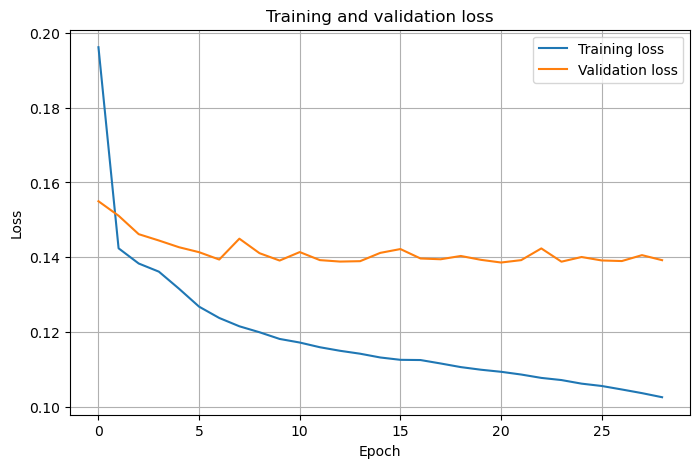

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(history_df["loss"], label="Training loss")
plt.plot(history_df["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(True)

plt.show()

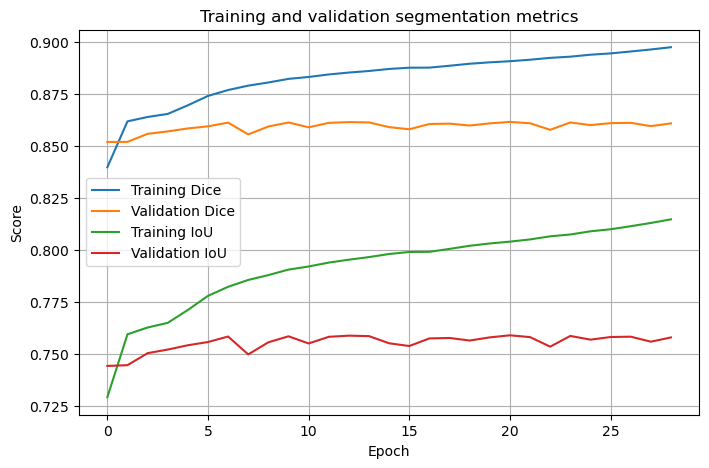

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(history_df["dice_score"], label="Training Dice")
plt.plot(history_df["val_dice_score"], label="Validation Dice")
plt.plot(history_df["iou_score"], label="Training IoU")
plt.plot(history_df["val_iou_score"], label="Validation IoU")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Training and validation segmentation metrics")
plt.legend()
plt.grid(True)

plt.show()

These curves are useful for checking that training is behaving sensibly. However, because this notebook is a workshop demonstration, the validation metrics should not be treated as a final estimate of model performance. Final inference and qualitative/quantitative assessment are covered in the next notebook.

## Conclusion

In this notebook, we walked through the main steps required to train a U-Net model for binary CT image segmentation.

We covered how to:

- build image-mask tables from the prepared datasets;
- split the data into training and validation sets;
- preprocess CT images and binary masks;
- create TensorFlow datasets;
- define a U-Net using `segmentation_models`;
- train the model using Dice loss, Dice score, and IoU score;
- use early stopping to monitor validation loss;
- save the trained model, training history, and configuration.

This notebook is intended as a training workflow demonstration. The validation metrics are useful for checking that the model is learning, but they should not be treated as the final assessment of model performance.

In Notebook 3, we will load the trained/pretrained model, run inference on CT data, visualise the predicted masks, and evaluate the model outputs.